Saving results in: Outputs_g_0_d_0
engine.exe configuration.in.example dt=0 output=Outputs_g_0_d_0/expl_dt=0.out alpha=1 tf=0.000 N0=0.000 g=0.0000 d=0.0000
Done.
engine.exe configuration.in.example dt=0 output=Outputs_g_0_d_0/expl_dt=0.out alpha=1 tf=0.000 N0=0.000 g=0.0000 d=0.0000
Done.
engine.exe configuration.in.example dt=0 output=Outputs_g_0_d_0/expl_dt=0.out alpha=1 tf=0.000 N0=0.000 g=0.0000 d=0.0000
Done.
engine.exe configuration.in.example dt=0 output=Outputs_g_0_d_0/expl_dt=0.out alpha=1 tf=0.000 N0=0.000 g=0.0000 d=0.0000
Done.
engine.exe configuration.in.example dt=0 output=Outputs_g_0_d_0/expl_dt=0.out alpha=1 tf=0.000 N0=0.000 g=0.0000 d=0.0000
Done.
engine.exe configuration.in.example dt=0 output=Outputs_g_0_d_0/expl_dt=0.out alpha=1 tf=0.000 N0=0.000 g=0.0000 d=0.0000
Done.


/var/folders/vc/2nmwr6j16r35rzclk48v0zp80000gn/T/ipykernel_43442/515968306.py:44: RuntimeWarning: invalid value encountered in scalar divide
  C = (N0-Nfp)/(N0+Nfp)
/bin/sh: engine.exe: command not found
/bin/sh: engine.exe: command not found
/bin/sh: engine.exe: command not found
/bin/sh: engine.exe: command not found
/bin/sh: engine.exe: command not found
/bin/sh: engine.exe: command not found


FileNotFoundError: [Errno 2] No such file or directory: 'Outputs_g_0_d_0/expl_dt=0.out'

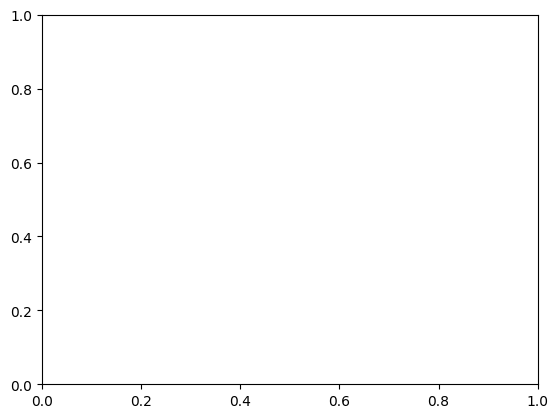

In [5]:
import numpy as np
import subprocess
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline # If you don't have this, you can use np.interp instead, but it may be less accurate
import os

# Parameters
repertoire = ''
executable = 'engine.exe' # Change this if your executable has a different name or path, like last week
input_filename = 'configuration.in.example'

tf = 0.0
N0 = 0.0
g = 0.0
d = 0.0



alpha = 1  # 1 explicit, 0 implicit, 0.5 semi-implicit

if alpha == 1:
    alphastr = "expl"
elif alpha == 0:
    alphastr = "impl"
else:
    alphastr = "semi_impl"

figstr = f"runaway_{alphastr}"

# -------------------------------------------------
# Create output directory (2 significant digits)
# -------------------------------------------------
outdir = f"Outputs_g_{g:.2g}_d_{d:.2g}"
os.makedirs(outdir, exist_ok=True)
print("Saving results in:", outdir)
# -------------------------------------------------

dt = tf / 2**np.arange(2, 8) #TODO: Adjust for your needs
nsimul = len(dt)

# Exact solution #TODO: Fill
Nfp = (g+np.sqrt(g**2+4*d))/2. # steady state solution at t=inf

C = (N0-Nfp)/(N0+Nfp)
    
Nf =  (1 + C*np.exp(-2*tf*Nfp))/(1-C*np.exp(-2*tf*Nfp)) # exact solution at tf

Nr = 0.2  # fraction of equilibrium defining characteristic time

# ---- exact characteristic time ----
t_ref = np.linspace(0, tf, 200000)

#TODO: calculate N_exact as function of time
N_exact = (1 + C*np.exp(-2*t_ref*Nfp))/(1-C*np.exp(-2*t_ref*Nfp)) # exact solution as function of time


ratio_exact = N_exact / Nfp
#TODO: calculate tau_ref as the time when ratio_exact crosses Nr, using interpolation
tau_ref = np.interp(Nr, ratio_exact, t_ref); 

paramstr = 'dt'
param = dt

# Simulations
outputs = []
totalsteps = []
tau_list = []
N_list = []
ratio = []
error = np.zeros(nsimul)

for i in range(nsimul):
    dt_val = param[i]  # current dt

    output_file = f"{alphastr}_dt={dt_val:.15g}.out"
    output_path = os.path.join(outdir, output_file)
    outputs.append(output_path)
    # Almost all parameters are passed as command line arguments, but you can also use an input file if you prefer. Adjust the command below accordingly.
    cmd = (
        f"{repertoire}{executable} {input_filename} "
        f"{paramstr}={dt_val:.15g} output={output_path}"
        f" alpha={alpha:.2g} tf={tf:.3f} N0={N0:.3f} g={g:.4f} d={d:.4f}"
    )

    print(cmd)
    subprocess.run(cmd, shell=True)
    print('Done.')

error = np.zeros(nsimul)

lw = 1.5
fs = 16

fig, axs = plt.subplots(1, 1)


for i in range(nsimul):
    with open(outputs[i]) as f:
        lines = f.readlines()

        total_steps = int(lines[-1].split(":")[1])
        data = np.loadtxt(lines[:-1])
        t = data[:, 0]
        N = data[:, 1]

        NN = N[-1]
        N_list.append(NN)
        totalsteps.append(total_steps)

        #TODO: calculate ratio and tau using interpolation, and store in tau_list
        ratio.append(NN/Nr) # ratio as function of time

        if ratio[0] <= Nr <= ratio[-1]: # Check if Nr is within the range of ratio for interpolation
            try:
                tau = np.interp(Nr, ratio, t) #TODO: interpolate to find tau where ratio crosses Nr
            except ValueError:
                tau = np.nan
        else:
            tau = np.nan

        tau_list.append(tau)

        error[i] = np.abs(1 - NN/Nf) #TODO: calculate relative error on Nf and store in error[i]

    axs.plot(t, N, label=f"dt={param[i]:.2e}", linewidth=lw, alpha=0.7)


plt.plot(t_ref, N_exact, 'k--', linewidth=2, label="Exact")
axs.set_xlabel(r'$\overline{t}$', fontsize=fs)
axs.set_ylabel(r'$\overline{N}$', fontsize=fs)
axs.set_xlim(0, tf)
axs.set_ylim(0, Nf*1.2)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(outdir, f"{figstr}_time.png"), dpi=300)

# Error vs dt
dtlist = dt

plt.figure()
plt.loglog(dtlist, error, 'r+-', label="numerical")
plt.loglog(dtlist, dtlist/1e6, 'k--', label="O(dt)")
plt.loglog(dtlist, dtlist**2/1e6, 'k-.', label="O(dt^2)")
plt.xlabel(r"d$\overline{t}$")
plt.ylabel("Relative error on Nf")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(outdir, f"{figstr}_Nf_error.png"), dpi=300)

# Convergence plot
plt.figure()
plt.plot(dtlist, N_list, 'r+-', label="numerical")
plt.axhline(Nf, color='k', linestyle='--', label="Exact")
plt.xlabel(r"d$\overline{t}$")
plt.ylabel(r"Final $\overline{N}$")
plt.xscale('log')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(outdir, f"{figstr}_Nf_conv.png"), dpi=300)

plt.figure()
plt.plot(dtlist, tau_list, 'r+-', label="numerical")
plt.axhline(tau_ref, color='k', linestyle='--', label="Exact")
plt.xlabel(r"d$\overline{t}$")
plt.ylabel(r"Characteristic time $\overline{\tau}$")
plt.xscale('log')
#plt.ylim(0, tf/10)  # Set y-limits to focus on the relevant range
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(outdir, f"{figstr}_tau.png"), dpi=300)

tau_err = np.abs(1 - np.array(tau_list) / tau_ref)

plt.figure()
plt.loglog(dtlist, tau_err, 'r+-', label="numerical")
plt.loglog(dtlist, dtlist, 'k--', label="O(dt)")
plt.loglog(dtlist, dtlist**2, 'k-.', label="O(dt^2)")
plt.xlabel(r"d$\overline{t}$")
plt.ylabel(r"Relative error on $\overline{\tau}$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(outdir, f"{figstr}_tau_error.png"), dpi=300)

plt.figure()
plt.loglog(totalsteps, tau_err, 'r+-', label=f"{alphastr}")
plt.xlabel("Total steps")
plt.ylabel("Relative error on tau")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(outdir, f"{figstr}_tau_error_vs_steps.png"), dpi=300)

In [3]:
!pip3 install numpy matplotlib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 19.8 MB/s  0:00:000.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 21.6 MB/s  0:00:002.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 20.5 MB/s  0:00:00 21.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 20.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 20.7 MB/s  0:00:002.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [matplotlib]37m━━━━ 8/9 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
